In [ ]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
def load_config(config_path):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

In [3]:
base_path = Path.cwd().parent
config_path = base_path / "config" / "config.yaml"
cfg = load_config(config_path)
data_path = cfg["paths"]["processed_path"]

In [4]:
df = pd.read_csv(base_path / data_path)

In [5]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,log_reviews,log_rpm,last_review_year,last_review_month,last_review_day,neigh_ad_rate,professional_host,estimated_booked_days
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,6,2.302585,0.190620,2018,10,19,0.005747,1,0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,2,3.828641,0.322083,2019,5,21,0.001295,1,10
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,1,0.000000,0.000000,1970,1,1,0.000377,0,0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,1,5.602119,1.729884,2019,7,5,0.001748,0,171
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,1,2.302585,0.095310,2018,11,19,0.000895,0,365


In [6]:
df.shape

(48870, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48870 entries, 0 to 48869
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48870 non-null  object 
 1   neighbourhood                   48870 non-null  object 
 2   latitude                        48870 non-null  float64
 3   longitude                       48870 non-null  float64
 4   room_type                       48870 non-null  object 
 5   price                           48870 non-null  int64  
 6   minimum_nights                  48870 non-null  int64  
 7   calculated_host_listings_count  48870 non-null  int64  
 8   log_reviews                     48870 non-null  float64
 9   log_rpm                         48870 non-null  float64
 10  last_review_year                48870 non-null  int64  
 11  last_review_month               48870 non-null  int64  
 12  last_review_day                 

In [8]:
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
calculated_host_listings_count    0
log_reviews                       0
log_rpm                           0
last_review_year                  0
last_review_month                 0
last_review_day                   0
neigh_ad_rate                     0
professional_host                 0
estimated_booked_days             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
X = df.drop("price", axis=1)
y = np.log1p(df["price"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
X_train.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,calculated_host_listings_count,log_reviews,log_rpm,last_review_year,last_review_month,last_review_day,neigh_ad_rate,professional_host,estimated_booked_days
42216,Bronx,Claremont Village,40.84355,-73.91103,Private room,1,1,2.197225,1.300192,2019,6,17,0.035714,0,7
28651,Manhattan,Upper East Side,40.76814,-73.95604,Private room,5,1,0.000000,0.000000,1970,1,1,0.000556,0,365
2633,Brooklyn,Crown Heights,40.67071,-73.94752,Entire home/apt,5,1,3.258097,0.300105,2019,1,2,0.000640,0,145
24953,Brooklyn,Flatbush,40.64063,-73.96348,Entire home/apt,4,1,2.890372,0.576613,2019,6,17,0.001610,0,270
9137,Manhattan,Harlem,40.80418,-73.95513,Private room,1,1,1.386294,0.058269,2015,8,21,0.000377,0,365


In [12]:
y_train.head(10)

42216    4.025352
28651    4.605170
2633     5.525453
24953    5.303305
9137     4.262680
29957    3.258097
10894    4.564348
4178     5.049856
43068    4.454347
15083    5.017280
Name: price, dtype: float64

In [13]:
freq_map = X_train["neighbourhood"].value_counts(normalize=True)

X_train["neighbourhood_freq"] = X_train["neighbourhood"].map(freq_map)
X_test["neighbourhood_freq"] = X_test["neighbourhood"].map(freq_map)

In [14]:
X_train = X_train.drop("neighbourhood", axis=1)
X_test = X_test.drop("neighbourhood", axis=1)

In [15]:
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "calculated_host_listings_count",
    "log_reviews",
    "last_review_year",
    "neigh_ad_rate",
    "estimated_booked_days",
    "neighbourhood_freq"
]

categorical_features = [
    "neighbourhood_group",
    "room_type"
]

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [17]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [18]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [19]:
y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

In [20]:
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test, y_pred)

print(f"mean absolute error: {mae}")
print(f"root mean squared error: {rmse}")
print(f"r2 score: {r2}")

mean absolute error: 57.12948143388938
root mean squared error: 229.0125739812516
r2 score: 0.6111341309437093


In [ ]:
param_dict = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

In [ ]:
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dict,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=1
)
search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [ ]:
print("Best hyperparameters:", search.best_params_)
print("Best CV score:", search.best_score_)

En iyi hiperparametreler: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 20}
En iyi CV skoru: 0.6105640889321962


In [24]:
y_pred = search.predict(X_test)

y_pred_original = np.expm1(y_pred)
y_test_original = np.expm1(y_test)

mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test, y_pred)

print(f"mean absolute error: {mae}")
print(f"root mean squared error: {rmse}")
print(f"r2 score: {r2}")

mean absolute error: 56.1929195671765
root mean squared error: 230.46971470178286
r2 score: 0.6200557733803107


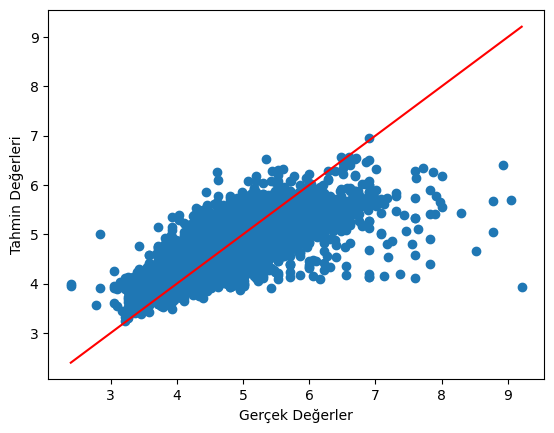

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Değerleri")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()